<a href="https://colab.research.google.com/github/20KaRaKuM20/NM/blob/main/%D0%BB%D1%809_%D0%92%D0%B8%D1%81%D0%BE%D1%86%D1%8C%D0%BA%D0%B8%D0%B9_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Варіант 3

Був присутній на парі  

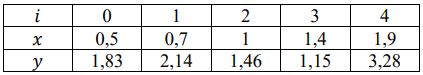

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [ ]:
import numpy as np

# Дані
x = np.array([0.5, 0.7, 1, 1.4, 1.9])
y = np.array([1.83, 2.14, 1.46, 1.15, 3.28])

n = len(x) - 1
h = np.diff(x)
a = y
b = np.zeros(n)
d = np.zeros(n)
c = np.zeros(n + 1)  # Розширюємо на один елемент для останнього індексу c[n]

alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])

l = np.ones(n + 1)  # Розширюємо l на один елемент
mu = np.zeros(n)
z = np.zeros(n + 1)  # Розширюємо на один елемент

# Пряма хода для знаходження l, mu, z
for i in range(1, n):
    l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
    mu[i] = h[i] / l[i]
    z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]

# Крайова умова: c[n] = 0
l[n] = 1
z[n] = 0
c[n] = 0

# Зворотний хід для знаходження c, b, d
for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j] * c[j+1]
    b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
    d[j] = (c[j+1] - c[j]) / (3 * h[j])

# Виведення аналітичного вигляду кубічного сплайну для кожного відрізка
for i in range(n):
    print(f"Відрізок {i+1}:")
    print(f"S_{i}(x) = {a[i]} + {b[i].round(4)}(x - {x[i]}) + {c[i].round(4)}(x - {x[i]})^2 + {d[i].round(4)}(x - {x[i]})^3, x належить [{x[i]}, {x[i+1]}]")

Відрізок 1:
S_0(x) = 1.83 + 2.3879(x - 0.5) + 0.0(x - 0.5)^2 + -20.9478(x - 0.5)^3, x належить [0.5, 0.7]
Відрізок 2:
S_1(x) = 2.14 + -0.1258(x - 0.7) + -12.5687(x - 0.7)^2 + 18.1083(x - 0.7)^3, x належить [0.7, 1.0]
Відрізок 3:
S_2(x) = 1.46 + -2.7778(x - 1.0) + 3.7288(x - 1.0)^2 + 3.1952(x - 1.0)^3, x належить [1.0, 1.4]
Відрізок 4:
S_3(x) = 1.15 + 1.739(x - 1.4) + 7.563(x - 1.4)^2 + -5.042(x - 1.4)^3, x належить [1.4, 1.9]


Побудова графіка

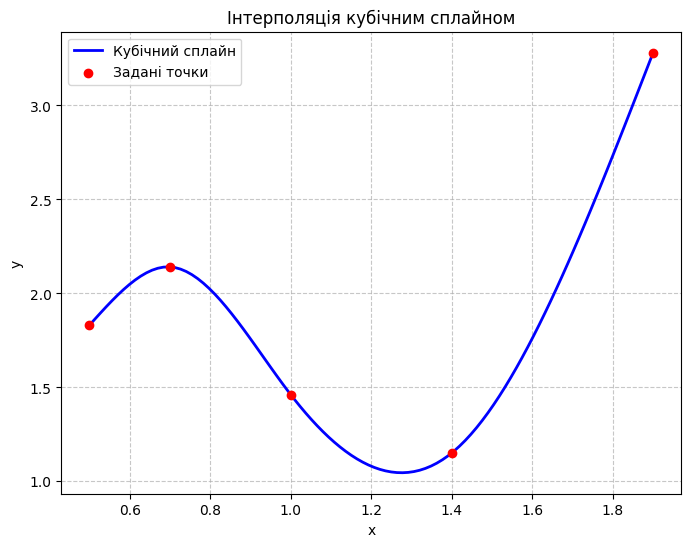

In [ ]:
# Діапазон для побудови графіка (100 точок між мінімумом та максимумом x)
x_values = np.linspace(np.min(x), np.max(x), 100)
y_values = []  # Список для значень сплайна

# Обчислення значень сплайна для кожного відрізка
for i in range(n):
    # Створюємо маску для вибору точок, що потрапляють у поточний інтервал [x[i], x[i+1]]
    mask = (x_values >= x[i]) & (x_values <= x[i + 1])
    x_interval = x_values[mask]

    # Обчислюємо значення полінома для цього інтервалу
    y_interval = a[i] + b[i] * (x_interval - x[i]) + \
                 c[i] * (x_interval - x[i])**2 + \
                 d[i] * (x_interval - x[i])**3

    y_values.extend(y_interval)

# Побудова графіка
plt.figure(figsize=(8, 6))
plt.plot(x_values, y_values, label="Кубічний сплайн", color='b', linewidth=2)
plt.scatter(x, y, label="Задані точки", color='r', zorder=5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Інтерполяція кубічним сплайном")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:

# Вхідні дані
x = np.array([0.5, 0.7, 1, 1.4, 1.9])
y = np.array([1.83, 2.14, 1.46, 1.15, 3.28])

# Побудова кубічного сплайну (natural забезпечує c[0]=c[n]=0)
cs = CubicSpline(x, y, bc_type='natural')

# Виведення коефіцієнтів сплайну для кожного відрізка
for i in range(len(x) - 1):
    # У Scipy коефіцієнти йдуть у порядку: [d, c, b, a] для ступенів 3, 2, 1, 0
    coeffs = cs.c[:, i]

    spline = (f"S_{i}(x) = {coeffs[3]:.4f} + {coeffs[2]:.4f}(x - {x[i]}) + "
              f"{coeffs[1]:.4f}(x - {x[i]})^2 + {coeffs[0]:.4f}(x - {x[i]})^3")

    print(spline)

S_0(x) = 1.8300 + 2.3879(x - 0.5) + 0.0000(x - 0.5)^2 + -20.9478(x - 0.5)^3
S_1(x) = 2.1400 + -0.1258(x - 0.7) + -12.5687(x - 0.7)^2 + 18.1083(x - 0.7)^3
S_2(x) = 1.4600 + -2.7778(x - 1.0) + 3.7288(x - 1.0)^2 + 3.1952(x - 1.0)^3
S_3(x) = 1.1500 + 1.7390(x - 1.4) + 7.5630(x - 1.4)^2 + -5.0420(x - 1.4)^3


Побудова графіка

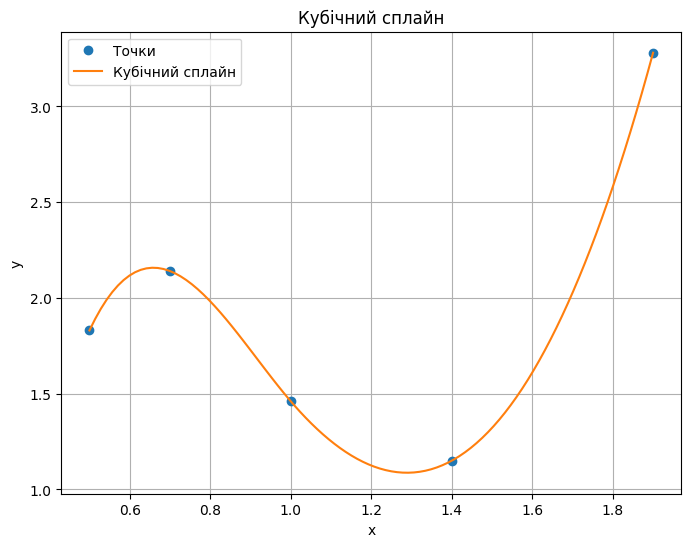

In [ ]:
# Побудова кубічного сплайна
cs = CubicSpline(x, y)
# Генерація нових точок для гладкого графіку сплайна
x_new = np.linspace(np.min(x), np.max(x), 100)
y_new = cs(x_new)
# Побудова графіку
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'o', label='Точки')
plt.plot(x_new, y_new, label='Кубічний сплайн')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Кубічний сплайн')
plt.legend()
plt.grid(True)
plt.show()